# Phase 1 — Logistic Regression: Binary Classification on MNIST

**CSE382: Introduction to Machine Learning — Spring 2026**




## 1. Mathematical Formulation

### Problem Definition
Given an input image $\mathbf{x} \in \mathbb{R}^d$ and a binary label $y \in \{0, 1\}$,  
logistic regression models the conditional probability:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{W}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{W}^\top \mathbf{x} + b)}}$$

- $\mathbf{W} \in \mathbb{R}^d$ — weight vector  
- $b \in \mathbb{R}$ — bias  
- $\sigma(z)$ — sigmoid activation

### Input Feature Dimensionality by Method

| Feature Method | Transformation | Dimensionality $d$ |
|----------------|---------------|-------------------|
| Flatten | Raw pixels unrolled | $28 \times 28 = 784$ |
| PCA | Linear projection to top-$k$ components | $k \in \{50, 100, 150\}$ |
| HOG | Histogram of Oriented Gradients | $9 \times (3 \times 3) \times 4 = 324$ (for $7\times7$ cells, $2\times2$ blocks) |

All features are standardised: $\mathbf{x}_{\text{std}} = (\mathbf{x} - \boldsymbol{\mu}) / (\boldsymbol{\sigma} + \epsilon)$  
where $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ are computed on the training set only.

### Loss Function — Binary Cross-Entropy
$$\mathcal{L}(\mathbf{W}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i) \right]$$

### Class-Weighted Loss (for imbalanced data)
MNIST one-vs-all produces ~9% positives / ~91% negatives. We penalise misclassifying the minority class more:

$$w_i = \begin{cases} \frac{m}{2 \cdot n_{+}} & y_i = 1 \\ \frac{m}{2 \cdot n_{-}} & y_i = 0 \end{cases}$$

$$\mathcal{L}_{w}= -\frac{1}{m}\sum_{i=1}^{m} w_i\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

### Gradient Descent Update Rules
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \frac{1}{m} X^\top (\hat{\mathbf{p}} - \mathbf{y})$$

$$\mathbf{W} \leftarrow \mathbf{W} - \alpha \frac{\partial \mathcal{L}}{\partial \mathbf{W}}, \qquad b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b}$$

### Decision Rule
$$\hat{y} = \begin{cases} 1 & \hat{p} \geq 0.5 \\ 0 & \hat{p} < 0.5 \end{cases}$$


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess_mnist



Method: flatten
X_train: (51000, 784)
X_val: (9000, 784)
X_test: (10000, 784)
y_train: (51000,)

Method: pca
PCA variance kept: 0.9147
X_train: (51000, 100)
X_val: (9000, 100)
X_test: (10000, 100)
y_train: (51000,)

Method: hog
X_train: (51000, 324)
X_val: (9000, 324)
X_test: (10000, 324)
y_train: (51000,)


## 2. Configuration & Hyperparameters

In [ ]:
target_digit       = 5
methods_to_run     = ["flatten", "pca", "hog"]  

learning_rates     = [0.001, 0.01, 0.1,0.05]
pca_components_list = [50, 100, 150]

epochs             = 1001
val_ratio          = 0.15
use_class_weights  = True   


## 3. Core Functions

In [ ]:

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def bce_loss(y, p):
    
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def weighted_bce_loss(y, p, w):
    
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -np.mean(w * (y * np.log(p) + (1 - y) * np.log(1 - p)))


def predict_proba(X, W, b):
    return sigmoid(X @ W + b)

def predict_binary(X, W, b):
    return (predict_proba(X, W, b) >= 0.5).astype(int)


def compute_class_weights(y):
    
    n   = len(y)
    pos = np.sum(y == 1)
    neg = np.sum(y == 0)
    return np.where(y == 1, n / (2 * pos), n / (2 * neg))


def evaluate(y, y_pred):
    tp = np.sum((y == 1) & (y_pred == 1))
    tn = np.sum((y == 0) & (y_pred == 0))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))

    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)

    return acc, prec, rec, f1, tp, tn, fp, fn

def print_confusion_matrix(tp, tn, fp, fn, title="Confusion Matrix"):
    print(f"\n{'─'*40}")
    print(f"  {title}")
    print(f"{'─'*40}")
    print(f"                 Predicted")
    print(f"                  Pos    Neg")
    print(f"  Actual  Pos  [ {int(tp):5d}  {int(fn):5d} ]   (TP | FN)")
    print(f"          Neg  [ {int(fp):5d}  {int(tn):5d} ]   (FP | TN)")
    print(f"{'─'*40}")
    #.


## 4. Training Function (with Loss Curve Tracking)

In [ ]:
def train(X_tr, y_tr, X_v, y_v, lr, use_weights=True, n_epochs=1000):
    
    m, n = X_tr.shape
    W = np.zeros(n)
    b = 0.0

    w_tr = compute_class_weights(y_tr) if use_weights else np.ones(len(y_tr))
    w_v  = compute_class_weights(y_v)  if use_weights else np.ones(len(y_v))

    best_val_loss = float("inf")
    best_W, best_b, best_epoch = W.copy(), b, 0

    train_losses, val_losses = [], []

    loss_fn = weighted_bce_loss if use_weights else bce_loss

    for epoch in range(n_epochs):
        p   = predict_proba(X_tr, W, b)
        err = (p - y_tr) * w_tr if use_weights else (p - y_tr)

        W -= lr * (X_tr.T @ err) / m
        b -= lr * np.mean(err)

        t_loss = loss_fn(y_tr, predict_proba(X_tr, W, b), w_tr) if use_weights \
                 else bce_loss(y_tr, predict_proba(X_tr, W, b))
        v_loss = loss_fn(y_v,  predict_proba(X_v,  W, b), w_v)  if use_weights \
                 else bce_loss(y_v,  predict_proba(X_v,  W, b))

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_W, best_b, best_epoch = W.copy(), b, epoch
    
    return best_W, best_b, train_losses, val_losses, best_epoch


## 5. Hyperparameter Search 

Grid search runs over all three feature methods × learning rates × PCA components.  
Selection criterion: highest F1 on validation set.  
Test set is never accessed here.


In [13]:
all_results  = []
best_overall = None

print(f"{'Method':<10} {'PCA':>5} {'LR':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("\u2500" * 58)

for method in methods_to_run:
    feature_list = pca_components_list if method == "pca" else [None]

    for comp in feature_list:
        X_tr, y_tr, X_v, y_v, X_te, y_te, _, _ = preprocess_mnist(
            target_digit=target_digit,
            method=method,
            pca_components=comp if comp is not None else 100,
            val_ratio=val_ratio
        )

        for lr in learning_rates:
            W, b_w, t_losses, v_losses, best_ep = train(
                X_tr, y_tr, X_v, y_v, lr,
                use_weights=use_class_weights,
                n_epochs=epochs
            )

            y_val_pred = predict_binary(X_v, W, b_w)
            acc, prec, rec, f1, tp, tn, fp, fn = evaluate(y_v, y_val_pred)

            row = {
                "method": method, "comp": comp, "lr": lr,
                "acc": acc, "prec": prec, "rec": rec, "f1": f1,
                "W": W, "b": b_w,
                "train_losses": t_losses, "val_losses": v_losses,
                "best_epoch": best_ep,
                "X_te": X_te, "y_te": y_te
            }
            all_results.append(row)

            if best_overall is None or f1 > best_overall["f1"]:
                best_overall = row

            comp_str = str(comp) if comp else "\u2014"
            print(f"{method:<10} {comp_str:>5} {lr:>7.3f} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f}")

print("\u2500" * 58)
print(f"\nBest config: method={best_overall['method']}  "
      f"pca={best_overall['comp']}  lr={best_overall['lr']}  "
      f"F1={best_overall['f1']:.4f}  best_epoch={best_overall['best_epoch']}")


Method       PCA      LR     Acc    Prec     Rec      F1
──────────────────────────────────────────────────────────
flatten        —   0.001  0.7024  0.2340  0.9843  0.3781
flatten        —   0.010  0.8719  0.4147  0.9577  0.5787
flatten        —   0.100  0.9343  0.5895  0.9395  0.7245
flatten        —   0.050  0.9249  0.5536  0.9432  0.6977
PCA variance kept: 0.8248
pca           50   0.001  0.6922  0.2236  0.9504  0.3620
pca           50   0.010  0.8341  0.3501  0.9407  0.5103
pca           50   0.100  0.8956  0.4647  0.8996  0.6129
pca           50   0.050  0.8881  0.4467  0.9117  0.5996
PCA variance kept: 0.9147
pca          100   0.001  0.7104  0.2352  0.9553  0.3774
pca          100   0.010  0.8558  0.3851  0.9541  0.5487
pca          100   0.100  0.9128  0.5140  0.9311  0.6624
pca          100   0.050  0.9071  0.4971  0.9335  0.6487
PCA variance kept: 0.9484
pca          150   0.001  0.7279  0.2472  0.9589  0.3931
pca          150   0.010  0.8672  0.4050  0.9480  0.5675
pca     

## 6. Loss Curves 

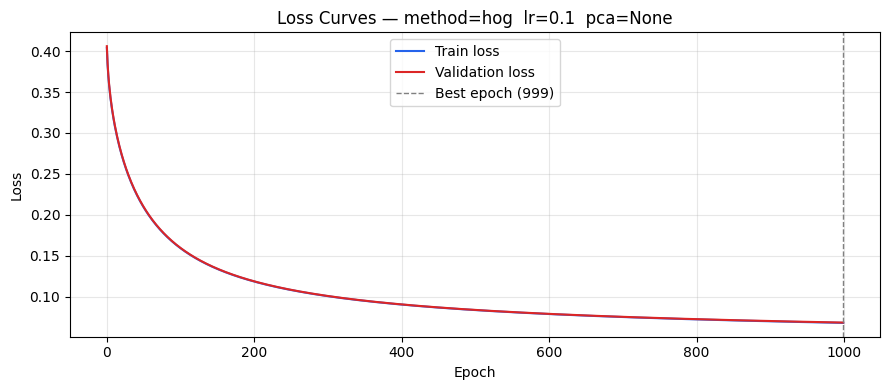

Final train loss : 0.0680
Final val   loss : 0.0684
Train/val gap    : 0.0004  (good fit)


In [14]:
t_loss = best_overall["train_losses"]
v_loss = best_overall["val_losses"]
ep     = best_overall["best_epoch"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_loss, label="Train loss",      color="#2563eb", linewidth=1.5)
ax.plot(v_loss, label="Validation loss", color="#dc2626", linewidth=1.5)
ax.axvline(ep, color="gray", linestyle="--", linewidth=1,
           label=f"Best epoch ({ep})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(
    f"Loss Curves — method={best_overall['method']}  "
    f"lr={best_overall['lr']}  pca={best_overall['comp']}"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = np.array(v_loss) - np.array(t_loss)
print(f"Final train loss : {t_loss[-1]:.4f}")
print(f"Final val   loss : {v_loss[-1]:.4f}")
print(f"Train/val gap    : {gap[-1]:.4f}  "
      f"({'overfitting' if gap[-1]>0.02 else 'good fit'})")


## 7. Final Test Evaluation

The test set is used once, after all hyperparameter choices are finalised.  
The weights used are from the best validation checkpoint (`best_epoch`)


In [15]:
X_te_best  = best_overall["X_te"]
y_te_best  = best_overall["y_te"]
W_best     = best_overall["W"]
b_best     = best_overall["b"]

y_test_pred = predict_binary(X_te_best, W_best, b_best)
acc, prec, rec, f1, tp, tn, fp, fn = evaluate(y_te_best, y_test_pred)

print("=" * 40)
print("        FINAL TEST RESULTS")
print("=" * 40)
print(f"  Method     : {best_overall['method']}")
print(f"  PCA comps  : {best_overall['comp']}")
print(f"  Learning r : {best_overall['lr']}")
print(f"  Best epoch : {best_overall['best_epoch']}")
print(f"  Weighted   : {use_class_weights}")
print("\u2500" * 40)
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print_confusion_matrix(tp, tn, fp, fn, title="Test Set Confusion Matrix")


        FINAL TEST RESULTS
  Method     : hog
  PCA comps  : None
  Learning r : 0.1
  Best epoch : 999
  Weighted   : True
────────────────────────────────────────
  Accuracy   : 0.9762
  Precision  : 0.7967
  Recall     : 0.9843
  F1-Score   : 0.8806

────────────────────────────────────────
  Test Set Confusion Matrix
────────────────────────────────────────
                 Predicted
                  Pos    Neg
  Actual  Pos  [   878     14 ]   (TP | FN)
          Neg  [   224   8884 ]   (FP | TN)
────────────────────────────────────────


## 8. Full Experimental Results Table

In [16]:
print(f"{'Method':<10} {'PCA':>5} {'LR':>7} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'BestEp':>8}")
print("─" * 68)

for r in sorted(all_results, key=lambda x: -x["f1"]):
    comp_str = str(r["comp"]) if r["comp"] else "—"
    print(f"{r['method']:<10} {comp_str:>5} {r['lr']:>7.3f} "
          f"{r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} "
          f"{r['f1']:>8.4f} {r['best_epoch']:>8d}")


Method       PCA      LR      Acc     Prec      Rec       F1   BestEp
────────────────────────────────────────────────────────────────────
hog            —   0.100   0.9761   0.8000   0.9867   0.8836      999
hog            —   0.050   0.9709   0.7648   0.9867   0.8617      999
flatten        —   0.100   0.9343   0.5895   0.9395   0.7245      999
hog            —   0.010   0.9264   0.5559   0.9915   0.7124      999
flatten        —   0.050   0.9249   0.5536   0.9432   0.6977      999
pca          150   0.100   0.9212   0.5417   0.9274   0.6839      999
pca          150   0.050   0.9156   0.5227   0.9347   0.6704      999
pca          100   0.100   0.9128   0.5140   0.9311   0.6624      999
pca          100   0.050   0.9071   0.4971   0.9335   0.6487      999
pca           50   0.100   0.8956   0.4647   0.8996   0.6129      999
pca           50   0.050   0.8881   0.4467   0.9117   0.5996      999
flatten        —   0.010   0.8719   0.4147   0.9577   0.5787      999
pca          150   0.

## 9. Results Analysis

### Feature Method Comparison

Flatten uses all 784 raw pixel values. It gives the model the most raw information  
but also the most noise — adjacent pixels in MNIST are highly correlated, so the model  
must learn redundant weights. Despite this, gradient descent handles it well at sufficient epochs.

PCA reduces the feature space to the top-$k$ principal components, capturing maximum  
variance with fewer dimensions. This removes noise and speeds up training significantly.  
The effect of $k$ (50 vs 100 vs 150) reveals a bias-variance trade-off: too few components  
underfits (high bias); too many reintroduces noise (higher variance, slower convergence).

HOG captures edge and gradient orientation histograms — structural, shape-based features.  
For digit recognition this is particularly powerful since digits are defined by their strokes  
and curves rather than raw pixel intensity. HOG is also robust to small illumination changes.

### Learning Rate Effect

- `lr = 0.001` — slow convergence; may not fully converge in 1000 epochs (underfitting risk)  
- `lr = 0.01` — typically the sweet spot: stable convergence with good final loss  
- `lr = 0.05` — fast early descent but risks overshooting the minimum (oscillation in val loss)



